### Pytorch Dataset and DataLoader

In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

DEVICE = (
    torch.device("mps")   if torch.backends.mps.is_available()
    else torch.device("cpu")
)
print(f"Using device: {DEVICE}")

CSV_PATH = Path("../data/cleaned_metadata.csv")
df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df):,} rows  |  train={len(df[df.split=='train']):,}  test={len(df[df.split=='test']):,}")

Using device: mps
Loaded 31,936 rows  |  train=25,548  test=6,388


In [2]:
IMG_SIZE = 260  # EfficientNet-B2 native resolution

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [3]:
class ClothingDataset(Dataset):
    """
    Returns front and back images as separate 3-channel tensors
    for the dual-stream architecture, plus a label dict.
    """

    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        front = Image.open(row["front_path"]).convert("RGB")
        back  = Image.open(row["back_path"]).convert("RGB")

        if self.transform:
            front = self.transform(front)
            back  = self.transform(back)

        labels = {
            "condition": torch.tensor(row["condition"] - 1, dtype=torch.long),
            "stains":    torch.tensor(row["stains"],        dtype=torch.long),
            "holes":     torch.tensor(row["holes"],         dtype=torch.long),
            "fraud":     torch.tensor(float(row["is_fraud_candidate"]), dtype=torch.float),
        }
        return front, back, labels

In [4]:
BATCH_SIZE = 32

train_df = df[df["split"] == "train"]
test_df  = df[df["split"] == "test"]

train_dataset = ClothingDataset(train_df, transform=train_transforms)
test_dataset  = ClothingDataset(test_df,  transform=test_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

print(f"Train: {len(train_dataset):,} items → {len(train_loader):,} batches")
print(f"Test:  {len(test_dataset):,} items → {len(test_loader):,} batches")

Train: 25,548 items → 799 batches
Test:  6,388 items → 200 batches


In [5]:
# Sanity check: load one batch and inspect shapes + label ranges
fronts, backs, labels = next(iter(train_loader))
print(f"Front batch shape : {fronts.shape}")       # (B, 3, 260, 260)
print(f"Back batch shape  : {backs.shape}")        # (B, 3, 260, 260)
print(f"Condition range   : {labels['condition'].min().item()} – {labels['condition'].max().item()}")

Front batch shape : torch.Size([32, 3, 260, 260])
Back batch shape  : torch.Size([32, 3, 260, 260])
Condition range   : 0 – 4


### Model Architecture 

In [6]:
import timm

class ClothingConditionModel(nn.Module):
    """
    Dual-stream model for clothing condition grading (5-class).

    Architecture
    ------------
    A shared EfficientNet-B2 backbone processes the front and back
    images independently (weight-shared, standard 3-channel input).
    The two 1408-d feature vectors are concatenated into a 2816-d
    representation and fed through a single classification head.
    """

    def __init__(self, backbone_name: str = "efficientnet_b2", pretrained: bool = True):
        super().__init__()

        self.backbone = timm.create_model(
            backbone_name,
            pretrained=pretrained,
            in_chans=3,
            num_classes=0,
            global_pool="avg",
        )

        feat_dim = self.backbone.num_features  # 1408

        self.head = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(feat_dim * 2, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 5),
        )

    def forward(self, front, back):
        f_front = self.backbone(front)   # (B, 1408)
        f_back  = self.backbone(back)    # (B, 1408)
        combined = torch.cat([f_front, f_back], dim=1)  # (B, 2816)
        return self.head(combined)       # (B, 5)

/opt/anaconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
model = ClothingConditionModel(pretrained=True).to(DEVICE)

# Phase 1: freeze backbone, only train the head
for param in model.backbone.parameters():
    param.requires_grad = False

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params     : {total_params:,}")
print(f"Trainable params : {trainable:,}  (backbone frozen)")
print(f"Backbone features: {model.backbone.num_features}")

# Verify forward pass with one batch
with torch.no_grad():
    out = model(fronts.to(DEVICE), backs.to(DEVICE))
    print(f"  condition logits → {out.shape}")

Total params     : 8,423,431
Trainable params : 722,437  (backbone frozen)
Backbone features: 1408
  condition logits → torch.Size([32, 5])


### Training Loop

In [8]:
from tqdm import tqdm

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [9]:
HEAD_LR       = 1e-3
BACKBONE_LR   = 1e-4
NUM_EPOCHS    = 10
UNFREEZE_AT   = 2
SAVE_DIR      = Path("../checkpoints")
SAVE_DIR.mkdir(exist_ok=True)

head_params = [p for n, p in model.named_parameters() if "backbone" not in n]
optimizer = torch.optim.AdamW(head_params, lr=HEAD_LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

def unfreeze_backbone(model, optimizer):
    """Unfreeze backbone and add its params to the optimizer with a lower LR."""
    for param in model.backbone.parameters():
        param.requires_grad = True
    optimizer.add_param_group({
        "params": list(model.backbone.parameters()),
        "lr": BACKBONE_LR,
        "weight_decay": 1e-4,
    })
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  ★ Backbone unfrozen — trainable params: {trainable:,}")

In [10]:
step_log = {"step": [], "loss": [], "acc": []}

def train_one_epoch(model, loader, optimizer, epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    window_loss = 0.0
    window_correct = 0
    window_total = 0

    num_batches = len(loader)
    log_every = max(1, num_batches // 20)
    global_offset = (epoch - 1) * num_batches

    pbar = tqdm(loader, desc="  train", leave=False)
    for batch_idx, (fronts, backs, labels) in enumerate(pbar):
        fronts = fronts.to(DEVICE)
        backs  = backs.to(DEVICE)
        targets = labels["condition"].to(DEVICE)

        logits = model(fronts, backs)
        loss = criterion(logits, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        bs = fronts.size(0)
        running_loss += loss.item() * bs
        correct += (logits.argmax(1) == targets).sum().item()
        total += bs

        window_loss += loss.item() * bs
        window_correct += (logits.argmax(1) == targets).sum().item()
        window_total += bs

        if (batch_idx + 1) % log_every == 0 or (batch_idx + 1) == num_batches:
            step_log["step"].append(global_offset + batch_idx + 1)
            step_log["loss"].append(window_loss / window_total)
            step_log["acc"].append(window_correct / window_total)
            window_loss = 0.0
            window_correct = 0
            window_total = 0

        if DEVICE.type == "mps":
            torch.mps.synchronize()

        pbar.set_postfix(loss=f"{loss.item():.3f}")

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for fronts, backs, labels in tqdm(loader, desc="  eval ", leave=False):
        fronts = fronts.to(DEVICE)
        backs  = backs.to(DEVICE)
        targets = labels["condition"].to(DEVICE)

        logits = model(fronts, backs)
        loss = criterion(logits, targets)

        running_loss += loss.item() * fronts.size(0)
        correct += (logits.argmax(1) == targets).sum().item()
        total += fronts.size(0)

    return running_loss / total, correct / total

In [11]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

best_val_loss = float("inf")

for epoch in range(1, NUM_EPOCHS + 1):
    if epoch == UNFREEZE_AT:
        unfreeze_backbone(model, optimizer)

    lrs = " / ".join(f"{g['lr']:.2e}" for g in optimizer.param_groups)
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}  (lr={lrs})")

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, epoch)
    val_loss, val_acc = evaluate(model, test_loader)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"  train  loss={train_loss:.4f}  acc={train_acc:.4f}")
    print(f"  val    loss={val_loss:.4f}  acc={val_acc:.4f}")

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_val_loss": best_val_loss,
        "history": history,
        "step_log": step_log,
    }
    torch.save(checkpoint, SAVE_DIR / "last_checkpoint.pt")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(checkpoint, SAVE_DIR / "best_checkpoint.pt")
        print(f"  ✓ saved best checkpoint (val_loss={val_loss:.4f})")

print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")


Epoch 1/10  (lr=1.00e-03)


  train  loss=1.4578  acc=0.3651
  val    loss=1.4200  acc=0.3929
  ✓ saved best checkpoint (val_loss=1.4200)
  ★ Backbone unfrozen — trainable params: 8,423,431

Epoch 2/10  (lr=9.76e-04 / 1.00e-04)


  train  loss=1.4124  acc=0.4039
  val    loss=1.3684  acc=0.4272
  ✓ saved best checkpoint (val_loss=1.3684)

Epoch 3/10  (lr=9.05e-04 / 9.27e-05)


  train  loss=1.3617  acc=0.4402
  val    loss=1.3660  acc=0.4148
  ✓ saved best checkpoint (val_loss=1.3660)

Epoch 4/10  (lr=7.94e-04 / 8.14e-05)


  train  loss=1.3265  acc=0.4596
  val    loss=1.3555  acc=0.4457
  ✓ saved best checkpoint (val_loss=1.3555)

Epoch 5/10  (lr=6.55e-04 / 6.71e-05)


...

  train  loss=1.2320  acc=0.5212
  val    loss=1.3479  acc=0.4599

Epoch 7/10  (lr=3.45e-04 / 3.54e-05)


  train  loss=1.1662  acc=0.5666
  val    loss=1.3657  acc=0.4565

Epoch 8/10  (lr=2.06e-04 / 2.11e-05)


  train  loss=1.1032  acc=0.6075
  val    loss=1.3916  acc=0.4573

Epoch 9/10  (lr=9.55e-05 / 9.79e-06)


  train  loss=1.0562  acc=0.6341
  val    loss=1.4467  acc=0.4436

Epoch 10/10  (lr=2.45e-05 / 2.51e-06)


  train  loss=1.0256  acc=0.6574
  val    loss=1.4426  acc=0.4516

Training complete. Best val loss: 1.3380


Time to run: 

In [12]:
import json as _json

# Save JSON copies of history for easy inspection outside of PyTorch
history_path  = SAVE_DIR / "training_history.json"
step_log_path = SAVE_DIR / "step_log.json"

with open(history_path, "w") as f:
    _json.dump(history, f, indent=2)
with open(step_log_path, "w") as f:
    _json.dump(step_log, f, indent=2)

print(f"Saved history  → {history_path}")
print(f"Saved step_log → {step_log_path}")
print(f"Full checkpoints in {SAVE_DIR}: best_checkpoint.pt, last_checkpoint.pt")

Saved history  → ../checkpoints/training_history.json
Saved step_log → ../checkpoints/step_log.json
Full checkpoints in ../checkpoints: best_checkpoint.pt, last_checkpoint.pt


In [13]:
import json as _json
from pathlib import Path as _Path

_save = _Path("../checkpoints")
try:
    _needs_reload = not history.get("train_loss")
except NameError:
    _needs_reload = True

if _needs_reload:
    _ckpt_path = _save / "last_checkpoint.pt"
    if _ckpt_path.exists():
        _ckpt = torch.load(_ckpt_path, map_location="cpu", weights_only=False)
        history  = _ckpt["history"]
        step_log = _ckpt["step_log"]
        print(f"Reloaded from checkpoint (epoch {_ckpt['epoch']})")
    else:
        with open(_save / "training_history.json") as f:
            history = _json.load(f)
        with open(_save / "step_log.json") as f:
            step_log = _json.load(f)
        print("Reloaded history & step_log from JSON")
else:
    print("Using in-memory history (no reload needed)")

Using in-memory history (no reload needed)


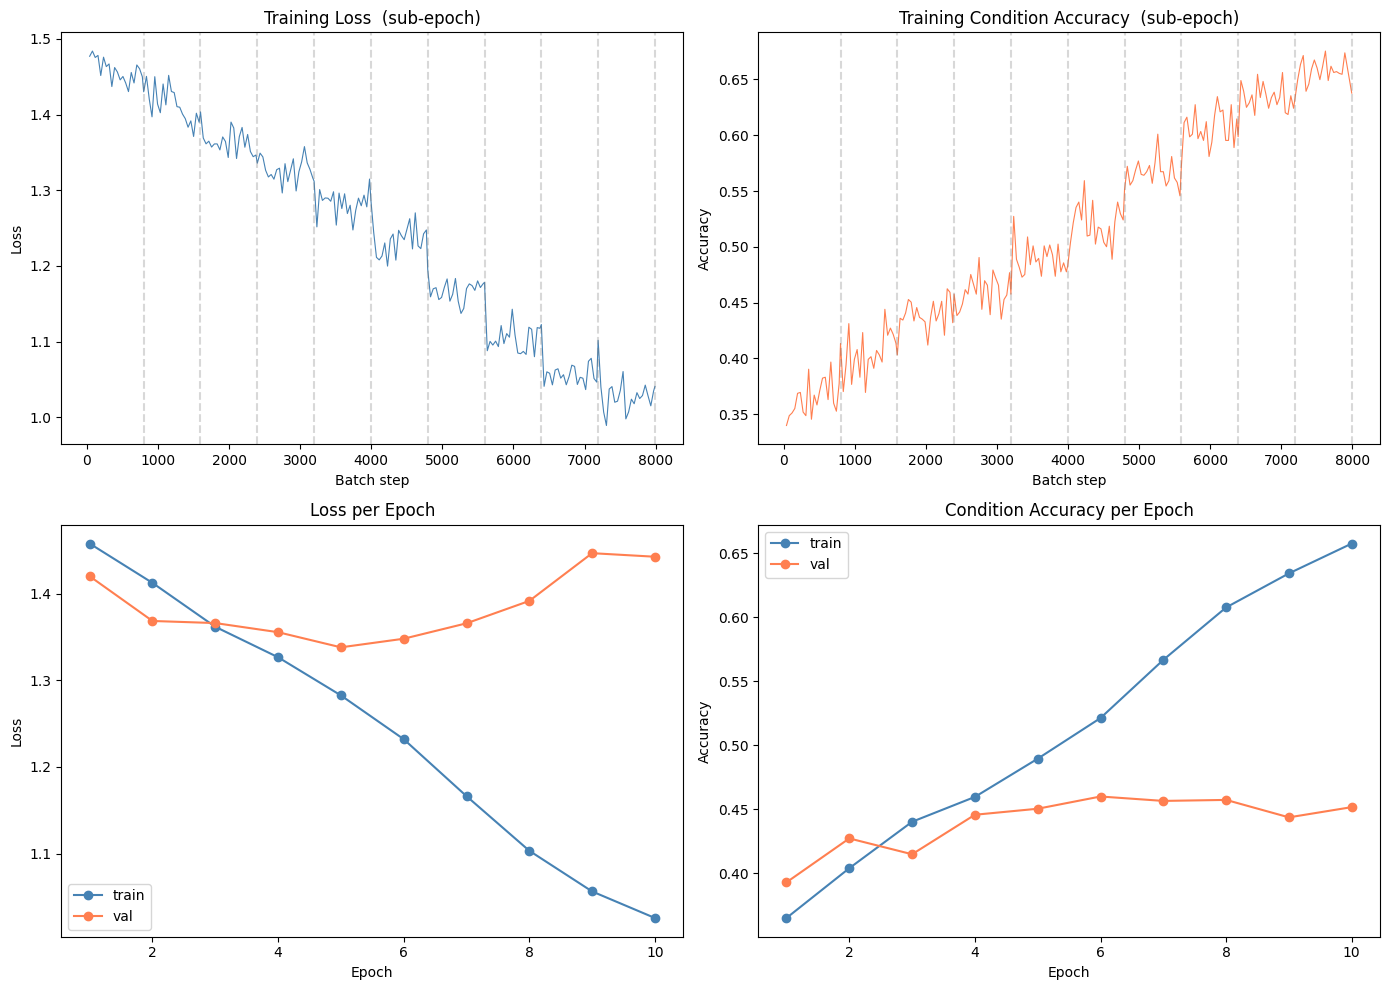

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Sub-epoch training curves
axes[0, 0].plot(step_log["step"], step_log["loss"], linewidth=0.8, color="steelblue")
axes[0, 0].set_title("Training Loss  (sub-epoch)")
axes[0, 0].set_xlabel("Batch step")
axes[0, 0].set_ylabel("Loss")
for e in range(1, NUM_EPOCHS + 1):
    axes[0, 0].axvline(x=e * len(train_loader), color="grey", linestyle="--", alpha=0.3)

axes[0, 1].plot(step_log["step"], step_log["acc"], linewidth=0.8, color="coral")
axes[0, 1].set_title("Training Condition Accuracy  (sub-epoch)")
axes[0, 1].set_xlabel("Batch step")
axes[0, 1].set_ylabel("Accuracy")
for e in range(1, NUM_EPOCHS + 1):
    axes[0, 1].axvline(x=e * len(train_loader), color="grey", linestyle="--", alpha=0.3)

# Per-epoch train vs val
epochs = range(1, len(history["train_loss"]) + 1)

axes[1, 0].plot(epochs, history["train_loss"], "o-", label="train", color="steelblue")
axes[1, 0].plot(epochs, history["val_loss"],   "o-", label="val",   color="coral")
axes[1, 0].set_title("Loss per Epoch")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Loss")
axes[1, 0].legend()

axes[1, 1].plot(epochs, history["train_acc"], "o-", label="train", color="steelblue")
axes[1, 1].plot(epochs, history["val_acc"],   "o-", label="val",   color="coral")
axes[1, 1].set_title("Condition Accuracy per Epoch")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### Evaluation and Reporting